$$$$

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt


np.random.seed(42)


mean = 100
#standard_deviation = ?


"""
Resistors are sorted into categories:
• 5% tolerance: within of 100 Q [95 Q, 105 Q]
• 10% tolerance: between and [90 Q, 95 Q) u (105 Q, 110 Q]
Out-of-spec: outside — (<90 Q) u (>110 Q)
"""

#q1
standard_deviation_1 = 5
less_then_90 = norm.cdf(90, loc=mean, scale=standard_deviation_1)
less_then_95 = norm.cdf(95, loc=mean, scale=standard_deviation_1)


p_10p_tolerance_half = less_then_95 - less_then_90

p_5p_tolerance_half = 0.5 - less_then_95


p_out_of_spec = less_then_90*2

p_10p_tolerance = p_10p_tolerance_half*2

p_5p_tolerance = p_5p_tolerance_half*2


print(f"""
Probability of 5% tolerance: {p_5p_tolerance:.2f}
Probability of 10% tolerance: {p_10p_tolerance:.2f}
Probability of out-of-spec: {p_out_of_spec:.2f}
Test results: {p_5p_tolerance + p_10p_tolerance + p_out_of_spec:.2f}
      """)


#q2
sim_data = np.random.normal(loc=mean, scale=standard_deviation_1, size=1000)

data_mask_out_of_spec = (sim_data < 90) | (sim_data > 110)
data_mask_p_5p_tolerance = ((sim_data < 95) & (sim_data >= 90)) | ((sim_data > 105) & (sim_data <= 110))
data_mask_p_10p_tolerance = ((sim_data < 100) & (sim_data >= 95)) | ((sim_data > 100) & (sim_data <= 105))

print(f"""
count_mask_p_10p_tolerance: {data_mask_p_10p_tolerance.sum()}
count_mask_p_5p_tolerance: {data_mask_p_5p_tolerance.sum()}
count_mask_out_of_spec: {data_mask_out_of_spec.sum()}
      """)



Probability of 5% tolerance: 0.68
Probability of 10% tolerance: 0.27
Probability of out-of-spec: 0.05
Test results: 1.00
      

count_mask_p_10p_tolerance: 698
count_mask_p_5p_tolerance: 261
count_mask_out_of_spec: 41
      


3) Tolerance -4 Standard deviation
Goal: Suppose the 5% package should contain half of all resistors.
Find o such that P (95 X S 105) 0.5 when X M (100, 02).

this fomular calculates the probability of a value being less than Z in a standard normal distribution:
$$\int_{-\infty}^{Z} \frac{1}{\sqrt{2\pi}} exp({\frac{-u^2}{2}})\,du$$

we can use this formula to find the Z value that corresponds to a cumulative probability of 0.25 (since we want the middle 50% to be between 95 and 105, we need to find the Z value that corresponds to the lower 25%):


$$\int_{-\infty}^{Z} \frac{1}{\sqrt{2\pi}} exp({\frac{-u^2}{2}})\,du=0.25\,\overset{solve, Z}{\rightarrow} Z \approx -0.674$$

$$\Phi(Z) \approx \Phi(\frac{x-\mu}{\sigma})$$

$$\Phi(-0.674) \approx \Phi(\frac{95-100}{\sigma})$$

$$-0.674 \approx \frac{95-100}{\sigma}$$

$$-0.674 \approx \frac{-5}{\sigma}$$

$$\sigma \approx \frac{-5}{-0.674} \approx 7.42$$


Probability of 5% tolerance: 0.50
      


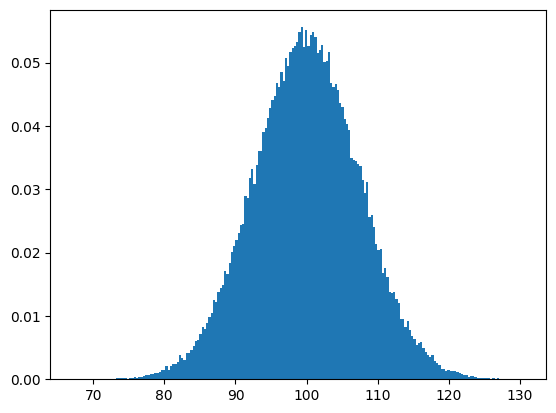

In [70]:
#test results
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import time

np.random.seed(int(time.time()))


mean = 100
standard_deviation = 7.42


less_then_95 = norm.cdf(95, loc=mean, scale=standard_deviation)


p_5p_tolerance_half = 0.5 - less_then_95



p_5p_tolerance = p_5p_tolerance_half*2


print(f"""
Probability of 5% tolerance: {p_5p_tolerance:.2f}
      """)




#q4
sim_data = np.random.normal(loc=mean, scale=standard_deviation, size=100000)


plt.hist(sim_data, bins=200, density=True)
plt.show()